 ### Student name: Kristyan Connolly

 ### Student ID: 25245295

In [45]:
# - Pandas
# - Numpy
# - Matplotlib
# - Seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler


# Task 1: Exploring the data (EDA)


Formulate a particular question that might be interesting to answer by exploring the bank dataset (approx. 50 words in a markdown cell).

Calculate statistics for the numerical and categorical attributes. Draw a short conclusion (approx. 150 words in a markdown cell).

Use at least two different plotting techniques to plot the distribution of some numerical attributes. Draw short conclusions (approx. 150 words in a markdown cell).

Generate at least two plots with the combined distribution of attributes. Draw a short conclusion (approx. 150 words in a markdown cell).

Make sure your conclusions are related to the question you have formulated.

### Question

Before I explore the data here is a question I would like to answer :

#### 1. How is balance related to age, education and job type?

I will focus on this quesion and these fields during the EDA.





### Stats

In [46]:
# First lets load the data into a dataframe
df = pd.read_csv('./bank.csv')

In [47]:
# Print first 5 rows of the dataframe
df.head(5)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
0,32.0,technician,single,tertiary,no,392,yes,no,cellular,1,apr,957,2,131,2,failure,no
1,39.0,technician,divorced,secondary,no,688,yes,yes,cellular,1,apr,233,2,133,1,failure,no
2,59.0,retired,married,secondary,no,1035,yes,yes,cellular,1,apr,126,2,239,1,failure,no
3,47.0,blue-collar,married,secondary,no,398,yes,yes,cellular,1,apr,274,1,238,2,failure,no
4,54.0,retired,married,secondary,no,1004,yes,no,cellular,1,apr,479,1,307,1,failure,no


In [48]:
# print last 5 rows of the dataframe
df.tail(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
1995,20.0,student,single,NaN,no,2785,no,no,cellular,16,sep,327,2,-1,0,NaN,yes
1996,28.0,admin.,single,secondary,no,127,no,no,cellular,16,sep,1334,2,-1,0,NaN,yes
1997,81.0,retired,married,primary,no,1154,no,no,telephone,17,sep,231,1,-1,0,NaN,yes
1998,46.0,services,married,primary,no,4343,yes,no,NaN,20,sep,185,1,-1,0,NaN,yes
1999,40.0,entrepreneur,married,secondary,no,6403,no,no,cellular,22,sep,208,2,-1,0,NaN,yes


In [49]:
# print the data types of the columns
print("Data types of the columns:") 
print(df.dtypes)


# Display dataset shape
print('\nDataset shape:', df.shape)


Data types of the columns:
age           float64
job               str
marital           str
education         str
default           str
balance         int64
housing           str
loan              str
contact           str
day             int64
month             str
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome          str
subscribed        str
dtype: object

Dataset shape: (2000, 17)


In [50]:
# Lets look at the summary statistics for numerical attributes

print("\nSummary statistics for numeric attributes:\n")

df.describe()


Summary statistics for numeric attributes:



,age,balance,day,duration,campaign,pdays,previous
count,1988.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,41.753018,1413.663500,13.851500,292.020500,1.909500,167.896000,2.561500
std,12.724358,3131.224213,9.712189,221.557295,1.378862,131.754126,3.400735
min,18.000000,-980.000000,1.000000,7.000000,1.000000,-1.000000,0.000000
25%,32.000000,201.500000,5.000000,146.000000,1.000000,75.750000,1.000000
50%,38.000000,551.000000,12.000000,236.000000,1.000000,182.000000,2.000000
75%,50.000000,1644.500000,23.000000,379.000000,2.000000,251.000000,3.000000
max,93.000000,81204.000000,31.000000,1823.000000,11.000000,854.000000,55.000000


In [51]:
# Frequency counts for categorical attributes
categorical_attributes  = df.select_dtypes(include=['str']).columns

print("\nCategorical attributes:\n")
print(list(categorical_attributes))

print("\nFrequency counts for categorical attributes:\n")

for column in categorical_attributes: 
    print("\n")
    print(df[column].value_counts(dropna=False))
    print("--------------------------------")


Categorical attributes:

['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'subscribed']

Frequency counts for categorical attributes:



job
management       461
technician       348
blue-collar      298
admin.           247
services         165
retired          162
student           96
unemployed        69
self-employed     64
entrepreneur      45
housemaid         35
NaN               10
Name: count, dtype: int64
--------------------------------


marital
married     1111
single       674
divorced     215
Name: count, dtype: int64
--------------------------------


education
secondary    995
tertiary     684
primary      217
NaN          104
Name: count, dtype: int64
--------------------------------


default
no     1985
yes      15
Name: count, dtype: int64
--------------------------------


housing
no     1037
yes     963
Name: count, dtype: int64
--------------------------------


loan
no     1750
yes     250
Name: count, dtype: int64


In [52]:
# Lets see if there are any missing values
df.isna().sum()

age            12
job            10
marital         0
education     104
default         0
balance         0
housing         0
loan            0
contact       191
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome      454
subscribed      0
dtype: int64

Now lets look for Outliers. I will use the Inter Quantile range to find outliers:

I check if a point is outside the domain (Q1 - 1.5*IQR, Q3 + 1.5*IQR), where IQR is the Inter Quartile Range, and Q1 is the first quartile and Q3 is the second quartile.

I calculate the total number of outliers together with the percentage of outliers for each column (outlier density)

In [53]:
# Function to print the IQR outlier information for a given column
# k is the multiplier for the IQR
# returns outlier rows using the IQR rule (Q1 - k*IQR, Q3 + k*IQR)
def print_iqr_outlier_info(df, column, k=1.5):
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - k * IQR
    upper_bound = Q3 + k * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"{column} column: Number of IQR Outliers: ", len(outliers))
    print("outlier density %: ", 100*len(outliers) / len(df))
    print("\n")
    

print_iqr_outlier_info(df, 'balance')
print_iqr_outlier_info(df, 'age')

balance column: Number of IQR Outliers:  158
outlier density %:  7.9


age column: Number of IQR Outliers:  24
outlier density %:  1.2




I want to look at the correlation between numerical value. I am particularily interested in the correlation between age and balance as it is relevent to the original question. A heat map will also help us to identify correlations.

               age   balance       day  duration  campaign     pdays  previous
age       1.000000  0.139874  0.042411  0.076732 -0.002876  0.009121  0.063805
balance   0.139874  1.000000  0.037078  0.096633  0.025103 -0.033014  0.030292
day       0.042411  0.037078  1.000000  0.058597 -0.019719  0.054188  0.063716
duration  0.076732  0.096633  0.058597  1.000000 -0.005188 -0.095650 -0.015965
campaign -0.002876  0.025103 -0.019719 -0.005188  1.000000  0.030929  0.140995
pdays     0.009121 -0.033014  0.054188 -0.095650  0.030929  1.000000  0.218636
previous  0.063805  0.030292  0.063716 -0.015965  0.140995  0.218636  1.000000


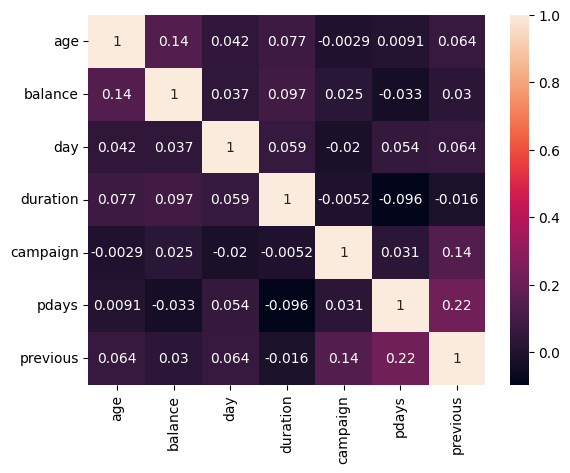

In [54]:
# correlation matrix
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True)
print(corr_matrix)

In summary, as can be seen above there are 2000 records containing both numerical and categorical attributes.

There are also a number of categorical and numerical columns that are empty.

age, job, education, contact and poutcome are attributes that contain empty data,&nbsp;

I noted that age is between 18 and 93 with a mean of 41.75 and a median of 38 with a standard deviation of 12.72. Because the mean is close to the median and the standard deviation is relativly small this looks reasonably symmetric with the average age close to middle age. There are also not too many outliers with only 1.2% of all datapoints considered to be outliers.

Balance varies quite a lot with a mean of 1413.663500 and a median of 551.00 and a relitevly large standard deviation of 3131.22. Theare  afew outliers with very high blances that are causing the mean to increase leading to skewness around the mean.
There are also quite a large number of outliers with 7.9% of values being ouliers. I might be worth removing thes eoutliers to get more accurate understanding of balance.

Balance and age also show a positive correlation of ~.14. But this is not very strong.

Age has 12 missing values, but given the small variance in values this should not cause too much impact on the age statistics calculations.  Luckily balance has no missing values as thta would be difficult to deal with given the skeness in the distribution.


#### Numercal Value plots

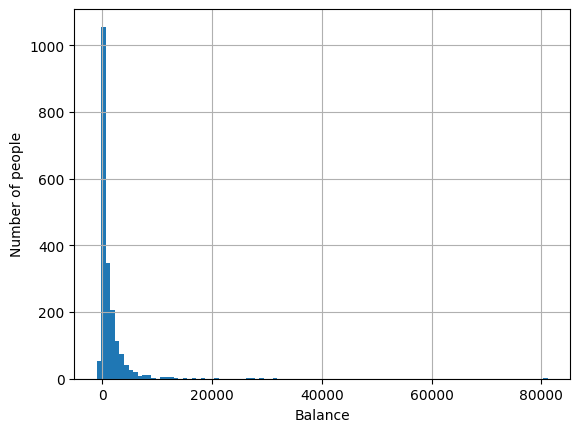

In [55]:
# lets see the distribution of balance
df['balance'].hist(bins=100)
plt.xlabel('Balance')
plt.ylabel('Number of people')
plt.show()

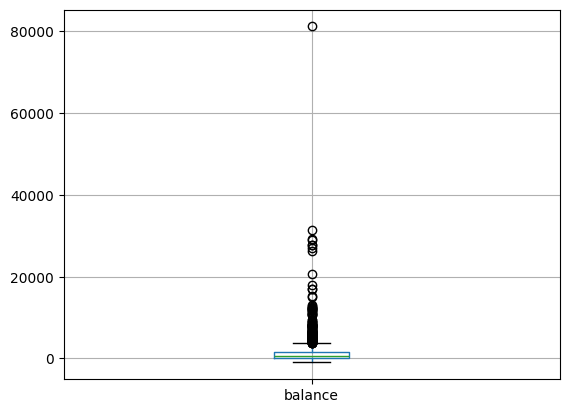

In [56]:
df.boxplot(column='balance')
plt.show()

As can be seen from the distribution plot and the boxplot above, the balance is right-skwewed due to the outliers especially the 81204 balance, which is a long way out. <br><br>
This has lead to quite a difference between the mean of 1413 and the median of 551.	<br><br>
Some of this may be due to different age groups, educations and jobs, but it would be interesting to remove these outliers to see how it effects the balance distrribution. It would lead to a dataset that is more symmetric and less skewed.


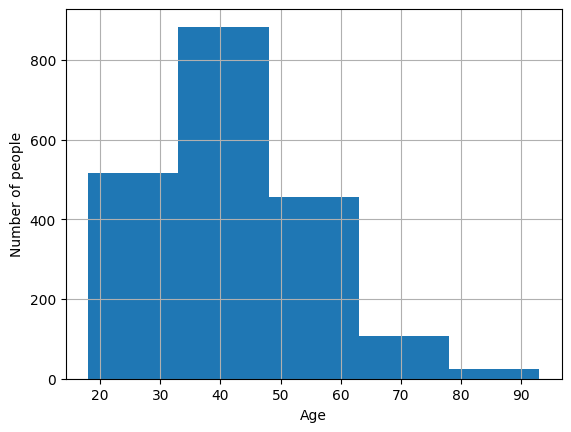

In [57]:
# lets see the distribution of age
df['age'].hist(bins=5)
plt.xlabel('Age')
plt.ylabel('Number of people')
plt.show()

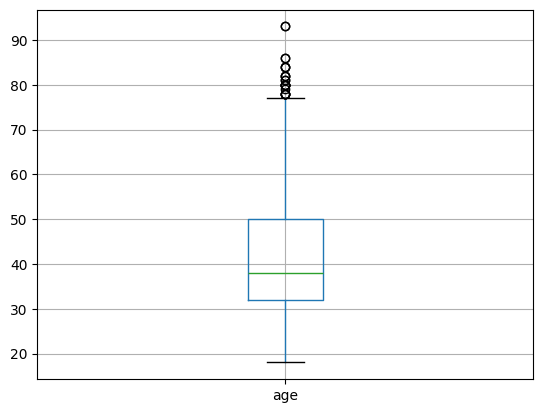

In [58]:
df.boxplot(column='age')
plt.show()

It can be seen from the above 2 plots of age that there are some outliers here around the age of 76+. <br>
We should consider removing these as they might not be be that interesting from a long term business perspective. <br>
Other than a few outliers the distribution of age looks fairly symmetric and not skewed too badly. The average age is around middle age with a mean of 41.75 and a median of 38.

### Combined Plots

#### Plots of Age and Balance

In [ ]:
# let look at some stats for balance grouped by age
df[['balance', 'age']].groupby(['age']).describe()

balance                                                                 \
       count          mean           std     min      25%     50%       75%   
age                                                                           
18.0     1.0    348.000000           NaN   348.0   348.00   348.0    348.00   
19.0     6.0    352.166667    161.409314   108.0   308.75   350.5    388.50   
20.0     2.0   1469.000000   1861.105048   153.0   811.00  1469.0   2127.00   
21.0     5.0   1267.800000   1093.681718    53.0   215.00  1506.0   2077.00   
22.0    18.0    961.555556    960.713780    71.0   232.75   666.0   1251.50   
...      ...           ...           ...     ...      ...     ...       ...   
81.0     2.0   1051.500000    144.956890   949.0  1000.25  1051.5   1102.75   
82.0     3.0    541.333333    737.253236     0.0   121.50   243.0    812.00   
84.0     3.0  28868.000000  45371.140530   639.0  2700.00  4761.0  42982.50   
86.0     2.0   3245.500000   2814.992096  1255.0  2250.25  3245.5   4240.75   
93.0     2.0    775.000000      0.000000   775.0   775.00   775.0    775.00   

               
          max  
age            
18.0    348.0  
19.0    608.0  
20.0   2785.0  
21.0   2488.0  
22.0   3472.0  
...       ...  
81.0   1154.0  
82.0   1381.0  
84.0  81204.0  
86.0   5236.0  
93.0    775.0  

[68 rows x 8 columns]

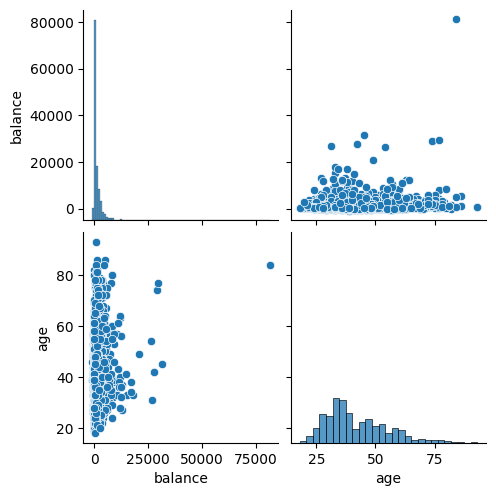

In [ ]:
# note that by applying the method dropna() we drop all rows with missing values 
sns.pairplot(data=df[['balance','age']].dropna())
plt.show()

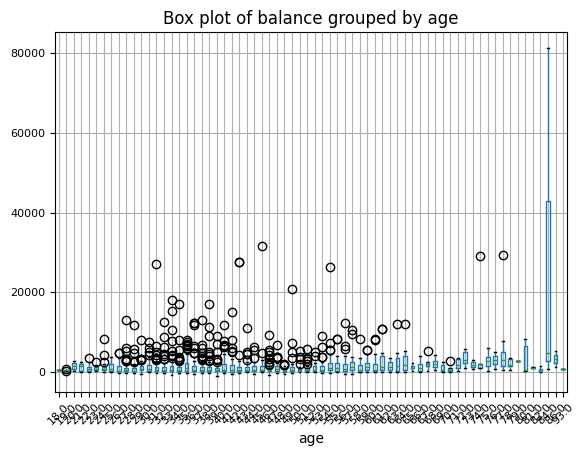

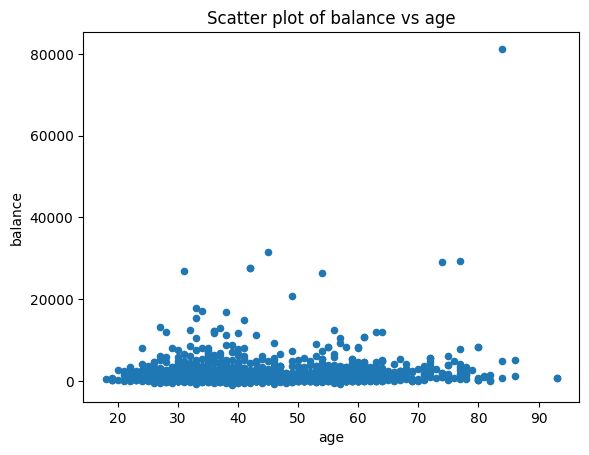

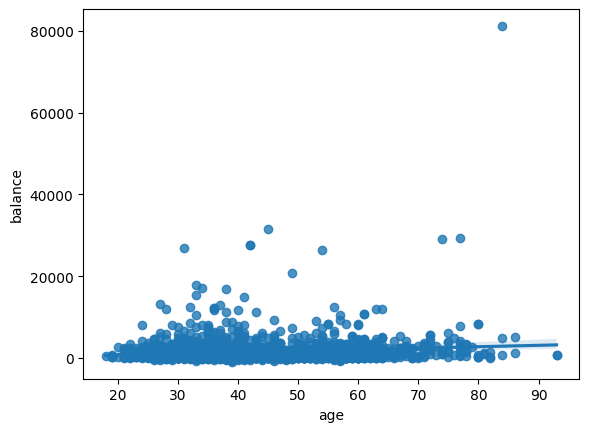

In [ ]:


# Box plots of balance, grouped by the age
df.boxplot(column='balance', by='age', rot=45, fontsize=8)
plt.title('Box plot of balance grouped by age')
plt.suptitle("") # get rid of the automatic 'Box plot grouped by group_by_column_name' title
plt.show()

# scatter plot of balance vs age
df.plot.scatter(x='age', y='balance')
plt.title('Scatter plot of balance vs age')
plt.show()

# regression plot of balance vs age
sns.regplot(data=df, x='age', y='balance')
plt.show()

In [ ]:
#let look at some stats for balance grouped by job
df[['balance', 'job']].groupby(['job']).describe()

balance                                                   \
                count         mean          std    min     25%     50%   
job                                                                      
admin.          247.0  1180.283401  1897.398373 -498.0  182.50   464.0   
blue-collar     298.0   737.295302  1347.420384 -768.0  100.50   360.0   
entrepreneur     45.0  1143.000000  1578.811334 -274.0  122.00   351.0   
housemaid        35.0  2327.914286  5004.958632 -184.0   56.50   605.0   
management      461.0  1768.227766  3391.802496 -980.0  275.00   698.0   
retired         162.0  2792.456790  7242.589061 -464.0  468.50  1242.5   
self-employed    64.0  1251.734375  2024.289750  -80.0  211.50   655.0   
services        165.0  1042.030303  1660.032377 -244.0  193.00   453.0   
student          96.0  1591.760417  2053.537224  -41.0  296.25   828.0   
technician      348.0  1199.683908  2141.403811 -735.0  192.50   481.0   
unemployed       69.0  1158.028986  1580.489025 -581.0  129.00   771.0   

                                 
                   75%      max  
job                              
admin.         1295.00  14968.0  
blue-collar     877.75  15341.0  
entrepreneur   1631.00   6403.0  
housemaid      2071.50  26965.0  
management     2016.00  31472.0  
retired        2809.25  81204.0  
self-employed  1508.75  10861.0  
services       1099.00  11650.0  
student        1933.00  13107.0  
technician     1284.50  16992.0  
unemployed     1416.00   7968.0

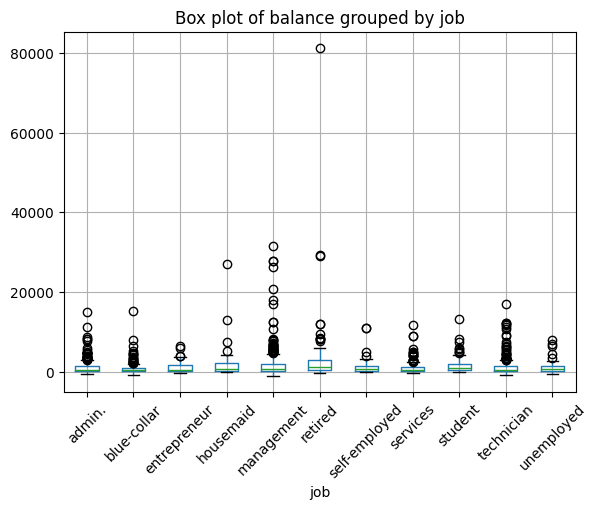

In [ ]:
# Box plots of balance, grouped by the categorical attribute age
df.boxplot(column='balance', by='job', rot=45, fontsize=10)
plt.title('Box plot of balance grouped by job')
plt.suptitle("") # get rid of the automatic 'Box plot grouped by group_by_column_name' title
plt.show()



In [ ]:
# let look at some stats for balance grouped by education
df[['balance', 'education']].groupby(['education']).describe()

balance                                                         \
            count         mean          std    min    25%    50%     75%   
education                                                                  
primary     217.0  1513.262673  3681.219279 -768.0  134.0  449.0  1452.0   
secondary   995.0  1220.836181  3100.896363 -735.0  194.0  505.0  1409.5   
tertiary    684.0  1667.609649  3130.537368 -980.0  224.0  629.5  1857.5   

                    
               max  
education           
primary    29340.0  
secondary  81204.0  
tertiary   31472.0

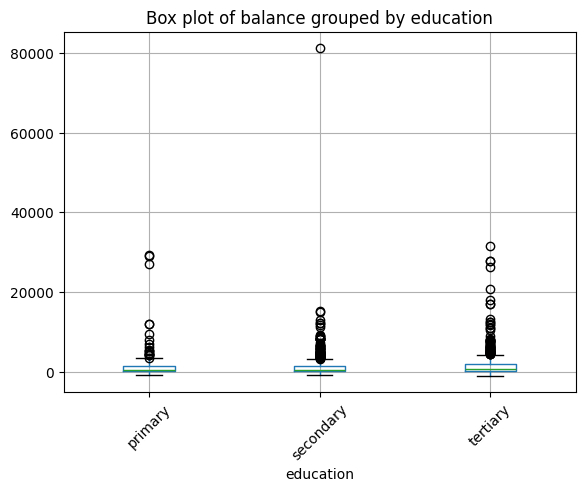

In [ ]:
# Box plots of balance, grouped by the categorical attribute education
df.boxplot(column='balance', by='education', rot=45, fontsize=10)
plt.title('Box plot of balance grouped by education')
plt.suptitle("") # get rid of the automatic 'Box plot grouped by group_by_column_name' title
plt.show()


Looking at the plots of balance vs age we can see that the correlation between the 2 is slightly positive but also very weak, which corresponds with what we seen in the data previously. There are also outliers across all age groups. Removal of these outliers might show a clearer relationship bewteen the balance and age in general.

Looking at the balance grouped by job, we can see that there are outliers for each job type, with management jobs having a lot of large balance outliers. Retired people have the the highest overall balances on average with blue-collar workers having some of the smallest balances.
In terms of outliers both entrepreneurs and self-employed people have very few large outliers, which may indicate that they do not leave larger balances of cash sitting in the bank.
Understandably unemployed people have some of the smallest balances with very few larger sums.

Looking at the balance grouped by education we can see that people with tertiary education generally have more savings than people with primary or secondary education. There doesnt appear to be too much differnce bwtween primary and secondary. This is however a couple of large outliers for primary that may be causing an overestimation in primary. Overall a higher education seems to have the effect to increase the average balance.

# Task 2: Data Preparation

In [ ]:
# lets make a copy of the original dataframe as we will be making changes to the original
df_original = df

df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
0,32.0,technician,single,tertiary,no,392,yes,no,cellular,1,apr,957,2,131,2,failure,no
1,39.0,technician,divorced,secondary,no,688,yes,yes,cellular,1,apr,233,2,133,1,failure,no
2,59.0,retired,married,secondary,no,1035,yes,yes,cellular,1,apr,126,2,239,1,failure,no
3,47.0,blue-collar,married,secondary,no,398,yes,yes,cellular,1,apr,274,1,238,2,failure,no
4,54.0,retired,married,secondary,no,1004,yes,no,cellular,1,apr,479,1,307,1,failure,no


In [ ]:
# Lets look at the missing values
df.isna().sum()


age            12
job            10
marital         0
education     104
default         0
balance         0
housing         0
loan            0
contact       191
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome      454
subscribed      0
dtype: int64

We can see that there are 5 columns with missing values and that job and education, contact and poutcome are categorical attributes that have missing values, so I will deal with these first. I also note that age has missing values so I will have to deal with that.

In [ ]:
# First lets encode the education column as it is an ordinal categorical column

# Create a mapper for the education column

education_mapper = {
    "primary": 0,
    "secondary": 1,
    "tertiary": 2
}

df['education'] = df['education'].replace(education_mapper)

df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
1995,20.0,student,single,NaN,no,2785,no,no,cellular,16,sep,327,2,-1,0,NaN,yes
1996,28.0,admin.,single,1,no,127,no,no,cellular,16,sep,1334,2,-1,0,NaN,yes
1997,81.0,retired,married,0,no,1154,no,no,telephone,17,sep,231,1,-1,0,NaN,yes
1998,46.0,services,married,0,no,4343,yes,no,NaN,20,sep,185,1,-1,0,NaN,yes
1999,40.0,entrepreneur,married,1,no,6403,no,no,cellular,22,sep,208,2,-1,0,NaN,yes


In [ ]:
# one-hot encode the categorical columns with NaNs
df = pd.get_dummies(df, columns=['job', 'education', 'contact', 'poutcome'], 
                        dummy_na=True, 
                        drop_first=True)
df.tail()


,age,marital,default,balance,housing,loan,day,month,duration,campaign,...,job_unemployed,job_nan,education_1,education_2,education_nan,contact_telephone,contact_nan,poutcome_other,poutcome_success,poutcome_nan
1995,20.0,single,no,2785,no,no,16,sep,327,2,...,False,False,False,False,True,False,False,False,False,True
1996,28.0,single,no,127,no,no,16,sep,1334,2,...,False,False,True,False,False,False,False,False,False,True
1997,81.0,married,no,1154,no,no,17,sep,231,1,...,False,False,False,False,False,True,False,False,False,True
1998,46.0,married,no,4343,yes,no,20,sep,185,1,...,False,False,False,False,False,False,True,False,False,True
1999,40.0,married,no,6403,no,no,22,sep,208,2,...,False,False,True,False,False,False,False,False,False,True


In [ ]:
#Next one-hot encode the other categorical columns
df = pd.get_dummies(df, drop_first=True)

df.tail()

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,subscribed_yes
1995,20.0,2785,16,327,2,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,True,True
1996,28.0,127,16,1334,2,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,True,True
1997,81.0,1154,17,231,1,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,True,True
1998,46.0,4343,20,185,1,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,True,True
1999,40.0,6403,22,208,2,-1,0,False,True,False,...,False,False,False,False,False,False,False,False,True,True


In [ ]:
# now lets fill the missing values for age using the median
df['age'] = df['age'].fillna(df['age'].median())

# Lets look at the missing values at this point
df.isna().sum()

age                  0
balance              0
day                  0
duration             0
campaign             0
pdays                0
previous             0
job_blue-collar      0
job_entrepreneur     0
job_housemaid        0
job_management       0
job_retired          0
job_self-employed    0
job_services         0
job_student          0
job_technician       0
job_unemployed       0
job_nan              0
education_1          0
education_2          0
education_nan        0
contact_telephone    0
contact_nan          0
poutcome_other       0
poutcome_success     0
poutcome_nan         0
marital_married      0
marital_single       0
default_yes          0
housing_yes          0
loan_yes             0
month_aug            0
month_dec            0
month_feb            0
month_jan            0
month_jul            0
month_jun            0
month_mar            0
month_may            0
month_nov            0
month_oct            0
month_sep            0
subscribed_yes       0
dtype: int6

Next I will look at rescaling. As noted earlier and as can be observed from the boxplot, the balance attribute has some outliers 

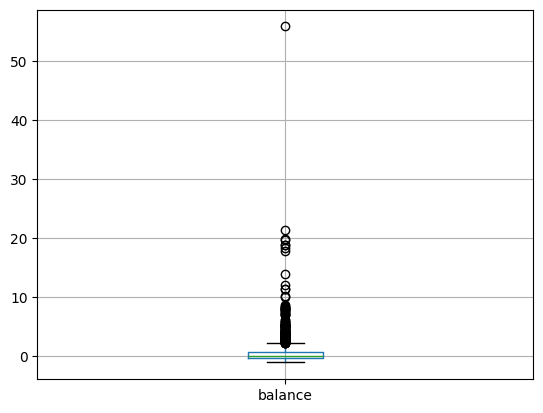

In [ ]:
robust_scaler = RobustScaler()
df[['balance']] = robust_scaler.fit_transform(df[['balance']])

df.boxplot(column=['balance'])
plt.show()